In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import numpy as np
import argparse
import matplotlib.gridspec as gridspec
import geopandas as gpd
from shapely.geometry import Point, Polygon
from matplotlib import font_manager

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 # Also recommended for PostScript output



In [4]:
def plot_ellipse(ax, data, color, label):
    """
    Plot an ellipse representing the 95% confidence interval of the data points.
    """
    mean = np.mean(data, axis=0)
    cov = np.cov(data.T)
    lambda_, v = np.linalg.eig(cov)
    lambda_ = np.sqrt(lambda_)
    
    # Scaling factor for the 95% confidence interval
    scaling_factor = np.sqrt(5.991)  # Chi-squared value for 2 degrees of freedom and 95% confidence
    
    # Calculate the angle of the ellipse
    angle = np.degrees(np.arctan2(*v[:, 0][::-1]))
    
    # Width and height are 2 standard deviations, scaled to the 95% confidence interval
    width, height = 2 * lambda_ * scaling_factor
    
    ellipse = Ellipse(xy=mean,
                      width=width, height=height,
                      angle=angle, color=color, linestyle='--', linewidth=1, fill=False)
    
    ax.add_patch(ellipse)
    ax.scatter(data[:, 0], data[:, 1], s=4, color=color)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Axes 1 explains 9.083669279087314% of the variance
Axes 2 explains 7.59191844984025% of the variance


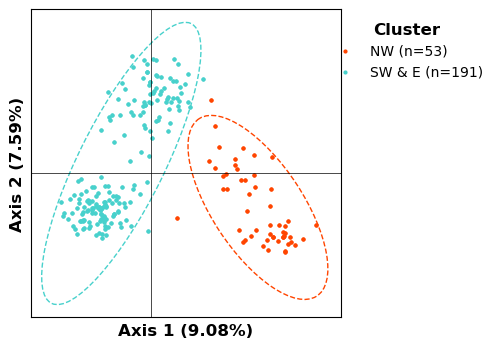

In [13]:
q_matrix_path = '../data/structure/q_matrix_2'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'
geno_path = "../data/genotypes/genotype_matrix.csv"


fig, ax = plt.subplots(figsize=(4,4))
X = pd.read_csv(geno_path, index_col=0)
reduction_obj = PCA(n_components=2, random_state=0)
projection = reduction_obj.fit_transform(X)
projection = pd.DataFrame(projection, columns=['PCA1', 'PCA2'])

q_matrix = pd.read_csv(q_matrix_path, index_col=0)
q_matrix = q_matrix.apply(pd.to_numeric)
q_matrix['max_prob'] = q_matrix.iloc[:, 1:].max(axis=1)
q_matrix['cluster_assignment'] = q_matrix.iloc[:, 1:-1].idxmax(axis=1)

merged_df = pd.merge(projection, q_matrix, left_index=True, right_index=True)

k = 2

colors = ['orangered', 'mediumturquoise', 'black', 'gold','magenta',
            'orange', 'red', 'aqua', 'hotpink', 'lime', 'blue']

cluster_labels = ['NW','E','SW'] # Adjust this appropiate 

for i in range(1, k+1):
    
    if k ==3:
        label = cluster_labels[i-1]
    elif k==2:
        cluster_labels = ['NW','SW & E']
        label = cluster_labels[i-1]
    else:
        label = str(i)
        
    cluster = merged_df.loc[merged_df.cluster_assignment == f'prop_{i}']
    n = len(cluster)
    if len(cluster) > 3:
        label_with_n = f"{label} (n={n})"
        ax.scatter(x='PCA1', y='PCA2', color=colors[i-1], s=4, data=cluster, label=label_with_n)
        plot_ellipse(ax, cluster[['PCA1', 'PCA2']].values, colors[i-1], label_with_n)


ax.set_xticks([])
ax.set_yticks([])
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

print(f"Axes 1 explains {reduction_obj.explained_variance_[0]}% of the variance")
print(f"Axes 2 explains {reduction_obj.explained_variance_[1]}% of the variance")

ax.set_xlabel(f'Axis 1 ({round(reduction_obj.explained_variance_[0],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)
ax.set_ylabel(f'Axis 2 ({round(reduction_obj.explained_variance_[1],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)

legend = ax.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.5, 1))
plt.setp(legend.get_title(), fontsize=12, fontweight='bold')
legend.set_frame_on(False)
plt.savefig('../PCA_k2.pdf',dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=True)
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Axes 1 explains 9.083669279087314% of the variance
Axes 2 explains 7.59191844984025% of the variance


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


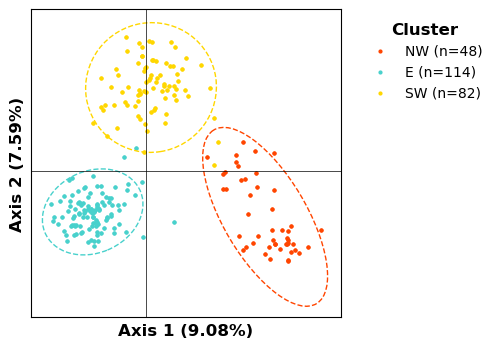

In [7]:
q_matrix_path = '../data/structure/q_matrix_3'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'
geno_path = "../data/genotypes/genotype_matrix.csv"


fig, ax = plt.subplots(figsize=(4,4))
X = pd.read_csv(geno_path, index_col=0)
reduction_obj = PCA(n_components=2, random_state=0)
projection = reduction_obj.fit_transform(X)
projection = pd.DataFrame(projection, columns=['PCA1', 'PCA2'])

q_matrix = pd.read_csv(q_matrix_path, index_col=0)
q_matrix = q_matrix.apply(pd.to_numeric)
q_matrix['max_prob'] = q_matrix.iloc[:, 1:].max(axis=1)
q_matrix['cluster_assignment'] = q_matrix.iloc[:, 1:-1].idxmax(axis=1)

merged_df = pd.merge(projection, q_matrix, left_index=True, right_index=True)

k = 3

colors = ['orangered', 'mediumturquoise', 'gold', 'gold','magenta',
            'orange', 'red', 'aqua', 'hotpink', 'lime', 'blue']

cluster_labels = ['NW','E','SW'] # Adjust this appropiate 

for i in range(1, k+1):
    
    if k ==3:
        label = cluster_labels[i-1]
    elif k==2:
        cluster_labels = ['NW','SW & E']
        label = cluster_labels[i-1]
    else:
        label = str(i)
        
    cluster = merged_df.loc[merged_df.cluster_assignment == f'prop_{i}']
    n = len(cluster)
    if len(cluster) > 3:
        label_with_n = f"{label} (n={n})"
        ax.scatter(x='PCA1', y='PCA2', color=colors[i-1], s=4, data=cluster, label=label_with_n)
        plot_ellipse(ax, cluster[['PCA1', 'PCA2']].values, colors[i-1], label_with_n)


ax.set_xticks([])
ax.set_yticks([])
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

print(f"Axes 1 explains {reduction_obj.explained_variance_[0]}% of the variance")
print(f"Axes 2 explains {reduction_obj.explained_variance_[1]}% of the variance")

ax.set_xlabel(f'Axis 1 ({round(reduction_obj.explained_variance_[0],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)
ax.set_ylabel(f'Axis 2 ({round(reduction_obj.explained_variance_[1],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)

legend = ax.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.5, 1))
plt.setp(legend.get_title(), fontsize=12, fontweight='bold')
legend.set_frame_on(False)
plt.savefig('../PCA_k3.pdf',dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=True)
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Axes 1 explains 9.083669279087314% of the variance
Axes 2 explains 7.59191844984025% of the variance


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


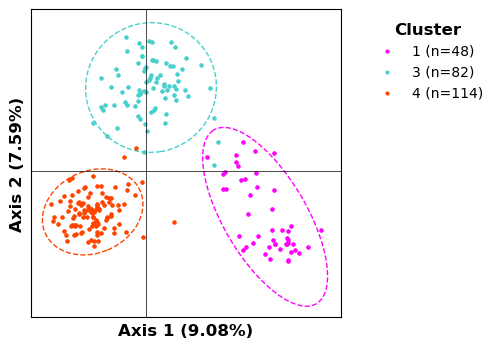

In [7]:
q_matrix_path = '../data/structure/q_matrix_4'
meta_path = '../config/meta_apriori_jittered.csv' 
bam_path = '../data/merged_bams/bams_4_rcr.txt'
geno_path = "../data/genotypes/genotype_matrix.csv"


fig, ax = plt.subplots(figsize=(4,4))
X = pd.read_csv(geno_path, index_col=0)
reduction_obj = PCA(n_components=2, random_state=0)
projection = reduction_obj.fit_transform(X)
projection = pd.DataFrame(projection, columns=['PCA1', 'PCA2'])

q_matrix = pd.read_csv(q_matrix_path, index_col=0)
q_matrix = q_matrix.apply(pd.to_numeric)
q_matrix['max_prob'] = q_matrix.iloc[:, 1:].max(axis=1)
q_matrix['cluster_assignment'] = q_matrix.iloc[:, 1:-1].idxmax(axis=1)

merged_df = pd.merge(projection, q_matrix, left_index=True, right_index=True)

k = 4

colors = ['magenta',  'gold', 'mediumturquoise','orangered']

cluster_labels = ['NW','NE','SW', 'SE'] # Adjust this appropiate 

for i in range(1, k+1):
    
    if k ==3:
        label = cluster_labels[i-1]
    elif k==2:
        cluster_labels = ['NW','SW & E']
        label = cluster_labels[i-1]
    else:
        label = str(i)
        
    cluster = merged_df.loc[merged_df.cluster_assignment == f'prop_{i}']
    n = len(cluster)
    if len(cluster) > 3:
        label_with_n = f"{label} (n={n})"
        ax.scatter(x='PCA1', y='PCA2', color=colors[i-1], s=4, data=cluster, label=label_with_n)
        plot_ellipse(ax, cluster[['PCA1', 'PCA2']].values, colors[i-1], label_with_n)


ax.set_xticks([])
ax.set_yticks([])
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

print(f"Axes 1 explains {reduction_obj.explained_variance_[0]}% of the variance")
print(f"Axes 2 explains {reduction_obj.explained_variance_[1]}% of the variance")

ax.set_xlabel(f'Axis 1 ({round(reduction_obj.explained_variance_[0],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)
ax.set_ylabel(f'Axis 2 ({round(reduction_obj.explained_variance_[1],2)}%)', fontname='Arial', fontweight='bold', fontsize=12)

legend = ax.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.5, 1))
plt.setp(legend.get_title(), fontsize=12, fontweight='bold')
legend.set_frame_on(False)
plt.savefig('../PCA_k4.pdf',dpi=300, bbox_inches='tight', pad_inches=0.02,
            transparent=False)
plt.show()